#Dataset LInk

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

#importing other modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm
import torch
import torch

# Check if CUDA is available and set the device index to 0
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
    print("CUDA device initialized:", torch.cuda.get_device_name(device))
else:
    print("CUDA is not available")

# Print PyTorch and CUDA versions
print(f"Using torch {torch.__version__} with CUDA {torch.version.cuda}")

# Memory summary
try:
    print(torch.cuda.memory_summary(device=device, abbreviated=False))
except KeyError as e:
    print(f"KeyError: {e}. Using abbreviated memory summary instead.")
    print(torch.cuda.memory_summary(device=device, abbreviated=True))

import os
os.chdir('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset')

CUDA device initialized: NVIDIA GeForce RTX 4090
Using torch 2.0.0+cu117 with CUDA 11.7
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  47821 KiB | 131798 KiB | 400792 GiB | 400792 GiB |
|       from large pool |  38326 KiB |  83367 KiB | 260780 GiB | 260780 GiB |
|       from small pool |   9495 KiB |  64283 KiB | 140011 GiB | 140011 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  47821 KiB | 131798 KiB | 40

#CODE

##Class Dataset

##Dataset Loader Class

In [15]:
from sklearn.model_selection import train_test_split
import torch
import pandas as pd
import numpy as np
batch_size = 10
import pandas as pd
# window size
batch_size = 10
def create_sequences(df, window_size=90):
    sequences = []
    labels = []
    for i in range(0, len(df) - window_size,1):
        window = df.iloc[i:i+window_size]
        sequence = window[['x', 'y', 'z']]
        label = window['label'].mode().values[0]
        sequences.append(sequence.values)
        labels.append(label)
    return sequences, labels

class HARDataset(torch.utils.data.Dataset):
  def __init__(self, seq, labels):
    super().__init__()
    self.data = torch.tensor(np.array(seq), dtype=torch.float32).unsqueeze(1)
    self.label = torch.tensor(np.array(labels))
    self.size = self.__len__()
    self.shape = self.data.shape

  def __len__(self):
        # Number of data point we have.
        return self.data.shape[0]

  def __getitem__(self, idx):
      # Return the idx-th data point of the dataset
      # If we have multiple things to return (data point and label), we can return them as tuple
      data_point = self.data[idx]
      data_point=data_point.squeeze()
      data_label = self.label[idx]
      return data_point, data_label

def save_seq_labels(sequences, labels):
    df = pd.DataFrame({'data': sequences, 'labels': labels})
    path = '/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Save_output/seq_label_save.csv'
    df.to_csv(path)



In [16]:
dataset_name="WISDM"
#dataset_name="USCHAD"
#dataset_name="PAMAP2"
#dataset_name="OpportunityUCI" #(31042, 25, 220) (31042,)
#dataset_name="Daphnet" #(29590, 25, 9)
#dataset_name="UCI_HAR" #(2922, 25, 562)

def Dataset_Selection(dataset_name="Wisdm"):
   if dataset_name=="WISDM":
      num_channels=3
      num_classes=6
      num_frames=90
      batch_size = 32
      max_time = 5
      #channel = 
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]
      frames=90
      scaled_data = pd.read_csv('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/Wisdm/ScaledData.csv')
      sequences, labels = create_sequences(scaled_data, window_size = 90)
      #save_seq_labels(sequences, labels)
      train_data, test_data, train_labels, test_labels = train_test_split(sequences, labels, test_size=0.2, random_state=42)

   if dataset_name=="USCHAD":
      num_channels=6
      num_classes=12
      num_frames=512
      batch_size = 32
      max_time = 5
      #channel = 3
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]
      frames=512
      #with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/USCHAD/train_merged_data.npz', allow_pickle=True) as data:
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/USCHAD/kshot_train_merged_data.npz', allow_pickle=True) as data:
         loaded = data['data'].item() 
         train_data = loaded['x']
         train_labels= loaded['y']
      
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/USCHAD/kshot_test_merged_data.npz', allow_pickle=True) as data:
         loaded = data['data'].item() 
         test_data = loaded['x']
         test_labels= loaded['y']
         
   if dataset_name=="PAMAP2":
      ''' 
      Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
      Counts of each label: [ 97 477 456 466 571 231 404 458 271 238 432 590]
      Number of unique labels: 12
      '''
      num_channels=40
      num_classes=12
      num_frames=25
      batch_size = 32
      max_time = 5
      #channel = 
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]
      frames=90
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/PAMAP2/pamap2.npz', allow_pickle=True) as data:
            sequences = data['data']
            labels = data['labels']
            train_data, test_data, train_labels, test_labels = train_test_split(sequences, labels, test_size=0.3, random_state=42)
   
   if dataset_name=="OpportunityUCI":
      num_channels=220
      num_classes=4
      num_frames=25
      batch_size = 32
      max_time = 5
      #channel = 
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]     
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/OpportunityUCI/OpportunityLocomotion.npz', allow_pickle=True) as data:
         sequences = data['data']
         labels = data['labels']
         train_data, test_data, train_labels, test_labels = train_test_split(sequences, labels, test_size=0.3, random_state=42)

   if dataset_name=="Daphnet":
      num_channels=9
      num_classes=2
      num_frames=25
      batch_size = 32
      max_time = 5
      #channel = 
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]     
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/Daphnet/Daphnet.npz', allow_pickle=True) as data:
         sequences = data['data']
         labels = data['labels']
         train_data, test_data, train_labels, test_labels = train_test_split(sequences, labels, test_size=0.3, random_state=42)

   if dataset_name=="UCI_HAR":
      num_channels=561
      num_classes=6
      num_frames=25
      batch_size = 32
      max_time = 5
      #channel = 
      kernel=[3, 3, 3]
      dilation=[1, 2, 4]     
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/UCI_HAR/train_UCA_HAR.npz', allow_pickle=True) as data:
         #loaded = data['data'].item() 
         train_data = data['data']
         train_labels= data['labels']
      
      with np.load('/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Dataset/UCI_HAR/test_UCA_HAR.npz', allow_pickle=True) as data:
         #loaded = data['data'].item() 
         test_data = data['data']
         test_labels= data['labels']


   def getData():
      #data = readRAWData()
      #scaled_data = preprocessData(data)
      train_dataset = HARDataset(train_data, train_labels)
      test_dataset = HARDataset(test_data, test_labels)
      print(train_dataset.shape)
      train_data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
      test_data_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
      return train_data_loader, test_data_loader
   
   train_data_loader, test_data_loader=getData()
   print("Successfully Completed the Dataset Loading:",dataset_name)
   return train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time

train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time=Dataset_Selection(dataset_name=dataset_name)

torch.Size([274658, 1, 90, 3])
Successfully Completed the Dataset Loading: WISDM


In [17]:
'''
import numpy as np
Model_No=11
dataset_name="WISDM"
#dataset_name="USCHAD"
#dataset_name="PAMAP2"
if __name__ == "__main__":
    train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time=Dataset_Selection(dataset_name="WISDM")
    print(len( train_data_loader))
    print(len(test_data_loader))
for i, (data, labels) in enumerate(train_data_loader):
  print(data.shape)
  print(labels.shape)
  if i==1:
     break
'''

'\nimport numpy as np\nModel_No=11\ndataset_name="WISDM"\n#dataset_name="USCHAD"\n#dataset_name="PAMAP2"\nif __name__ == "__main__":\n    train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time=Dataset_Selection(dataset_name="WISDM")\n    print(len( train_data_loader))\n    print(len(test_data_loader))\nfor i, (data, labels) in enumerate(train_data_loader):\n  print(data.shape)\n  print(labels.shape)\n  if i==1:\n     break\n'

#Model

##TCN  previous dimension; (25481, 50, 8)

In [18]:
#https://github.com/morgengramlich/temporal_convolutional_network
import torch
from torch import nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    '''Residual block to use in TCN'''
    def __init__(self, input_size, hidden_size, kernel_size, dilation):
        super(ResidualBlock, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.pad1 = nn.ConstantPad1d(((self.kernel_size-1)*dilation, 0), 0.0)
        self.conv1 = nn.utils.weight_norm(nn.Conv1d(
            in_channels=self.input_size,
            out_channels=self.hidden_size,
            kernel_size=self.kernel_size,
            dilation=dilation,
        ))
        self.dropout1 = nn.Dropout(p=0.2)
        self.pad2 = nn.ConstantPad1d(((self.kernel_size-1)*dilation, 0), 0.0)
        self.conv2 = nn.utils.weight_norm(nn.Conv1d(
            in_channels=self.hidden_size,
            out_channels=self.input_size,
            kernel_size=self.kernel_size,
            dilation=dilation,
        ))
        self.dropout2 = nn.Dropout(p=0.2)
    def forward(self, x):
        '''One step of computation'''
        output = self.pad1(x)
        output = F.relu(self.conv1(output))
        output = self.dropout1(output)
        output = self.pad2(output)
        output = F.relu(self.conv2(output))
        output = self.dropout2(output)
        return F.relu(x + output)
    
class TCN(nn.Module):
    '''Temporal Convolutional Network'''
    def __init__(self, input_size, ouput_size, kernel_sizes, dilations):
        super(TCN, self).__init__()
        if len(kernel_sizes) != len(dilations):
            raise ValueError('kernel_sizes and dilations must be of the same size')
        self.input_size = input_size
        self.output_size=ouput_size
        self.kernel_sizes = kernel_sizes
        self.dilations = dilations
        self.residuals = nn.Sequential()
        for n in range(len(kernel_sizes)):
            self.residuals.append(ResidualBlock(self.input_size, self.input_size, self.kernel_sizes[n], self.dilations[n]))
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(self.input_size, self.output_size)

    def forward(self, value):
        '''One step of computation'''
        output = torch.permute(value, (0, 2, 1))
        #print("output = torch.permute(value, (0, 2, 1)):",output.shape)
        output = self.residuals(output)
        output = torch.permute(output, (0, 2, 1))
        output = self.dropout(output)
        output = self.fc(output)
        return output
#input=batch*frame*channel
import random
import math
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
from random import randint,shuffle
import torch.nn as nn
import torch.nn.functional as F

class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, ft_dim, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(ft_dim))
        self.b_2 = nn.Parameter(torch.zeros(ft_dim))
        self.eps = eps

    def forward(self, x):
        #[batch, time, ft_dim)
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2
    

'''
#function calling:
import torch
from torch import nn
input_size = num_channels  # Adjust as necessary
output_size = 6  # Adjust as necessary
kernel_sizes = [3, 3, 3]  # Example values
dilations = [1, 2, 4]  # Example values
tcn = TCN(input_size=input_size, ouput_size=output_size, kernel_sizes=kernel_sizes, dilations=dilations)
# Create a random sample input
batch_size = 32
seq_length = num_frames
num_features = input_size
sample_input = torch.randn(batch_size, seq_length, num_features)

# Forward pass through the TCN
output = tcn(sample_input)
'''

'\n#function calling:\nimport torch\nfrom torch import nn\ninput_size = num_channels  # Adjust as necessary\noutput_size = 6  # Adjust as necessary\nkernel_sizes = [3, 3, 3]  # Example values\ndilations = [1, 2, 4]  # Example values\ntcn = TCN(input_size=input_size, ouput_size=output_size, kernel_sizes=kernel_sizes, dilations=dilations)\n# Create a random sample input\nbatch_size = 32\nseq_length = num_frames\nnum_features = input_size\nsample_input = torch.randn(batch_size, seq_length, num_features)\n\n# Forward pass through the TCN\noutput = tcn(sample_input)\n'

##Musa Models

In [32]:

import torch
import torch.nn as nn
import torch.nn.functional as F
Model_No=7

#model-1:  TCN		Softmax


class Musa_TCN_Model1(nn.Module):
    def __init__(self, channel=3, num_classes=6, frame=90, dp_rate=0.1):
        super(Musa_TCN_Model1, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.cls = nn.Linear(self.output_shape * 1, num_classes)

    def forward(self, x):
        # Assuming x is the input tensor of shape (batch_size, sequence_length, channel)
        # Initial feature extraction
        initial_feature = x
        tcn1_out = self.tcn1(x)
        concat_features = tcn1_out
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred


#model-2:  TCN+TCN		Softmax
class Musa_TCN_Model2(nn.Module):
    def __init__(self, channel=3, num_classes=6, frame=90, dp_rate=0.1):
        super(Musa_TCN_Model2, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape=32
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.cls = nn.Linear(self.output_shape * 2, num_classes)

    def forward(self, x):
        # Assuming x is the input tensor of shape (batch_size, sequence_length, channel)
        # Initial feature extraction
        initial_feature = x
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn1(x)
        concat_features = torch.cat((tcn1_out, tcn2_out), dim=2)
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred

#model-3:  TCN+TCN+TCN		Softmax

import torch
import torch.nn as nn
class Musa_TCN_Model3(nn.Module):
    def __init__(self, channel=3, num_classes=6, frame=90, dp_rate=0.1):
        super(Musa_TCN_Model3, self).__init__()
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape=32
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.cls = nn.Linear(self.output_shape * 3, num_classes)
    def forward(self, x):
        initial_feature = x
        # Apply TCN
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn1(x)
        tcn3_out = self.tcn1(x)
        concat_features = torch.cat((tcn1_out, tcn2_out, tcn3_out), dim=2)          
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred
#model-4:  TCN+TCN+TCN+TCN		Softmax       

import torch
import torch.nn as nn
class Musa_TCN_Model4(nn.Module):
    def __init__(self, channel=3, num_classes=6, frame=90, dp_rate=0.1):
        super(Musa_TCN_Model4, self).__init__()
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape=32
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.cls = nn.Linear(self.output_shape * 4, num_classes)
    def forward(self, x):
        initial_feature = x
        # Apply TCN
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn1(x)
        tcn3_out = self.tcn1(x)
        tcn4_out = self.tcn1(x)
        concat_features = torch.cat((tcn1_out, tcn2_out, tcn3_out,tcn4_out), dim=2)          
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred
        
#model-5:  TCN, TCN+CNN		Softmax    

class Musa_TCN_Model5(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model5, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
        self.cls = nn.Linear(self.output_shape * 2, num_classes)
    def forward(self, x):
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn2(x)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        conv1d_out = self.conv1d(tcn2_out)
        conv1d_out =conv1d_out.permute(0, 2, 1)
        concat_features = torch.cat((tcn1_out, conv1d_out), dim=2)
        
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred
        
#model-6:  TCN, TCN+CNN, TCN+LSTM		Softmax 

class Musa_TCN_Model6(nn.Module):
        def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
            super(Musa_TCN_Model6, self).__init__()           
            self.channel = channel
            self.num_classes = num_classes
            self.frame = frame
            self.dp_rate = dp_rate
            self.output_shape = 32  # Adjust as necessary based on TCN output
            self.kernel = [3, 3, 3]
            self.dilation = [1, 2, 4]
            self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
            self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
            self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
            self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
            
            self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
            self.cls = nn.Linear(self.output_shape * 3, num_classes)

        def forward(self, x):
            tcn1_out = self.tcn1(x)
            tcn2_out = self.tcn2(x)
            tcn3_out = self.tcn3(x)
            lstm_out, _ = self.lstm(tcn1_out)
            tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
            conv1d_out = self.conv1d(tcn2_out)
            conv1d_out =conv1d_out.permute(0, 2, 1)
            concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out), dim=2)
            avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
            avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
            pred = self.cls(avg_pool)
            return pred

 #TCN,  TCN+CNN, TCN+LSTM, LSTM+TCN, Softmax
class Musa_TCN_Model7(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model7, self).__init__()
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn4 = TCN(self.output_shape, self.output_shape, self.kernel, self.dilation)
        self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.lstm_TCN = nn.LSTM(input_size=channel, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
        self.cls = nn.Linear(self.output_shape * 4, num_classes)

    def forward(self, x):
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn2(x)
        tcn3_out = self.tcn3(x)
        lstm_out, _ = self.lstm(tcn1_out)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        conv1d_out = self.conv1d(tcn2_out)
        conv1d_out =conv1d_out.permute(0, 2, 1)
        lstm_tcn_out, _ = self.lstm_TCN(x)
        tcn4_out = self.tcn4(lstm_tcn_out)
        concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out,tcn4_out), dim=2)
        #concat_features = self.se_block( concat_features.permute(0, 2, 1)).permute(0, 2, 1)
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred

#if Model_No==8: #TCN, TCN+LSTM, LSTM+TCN, TCN+CNN	MHSA

class Musa_TCN_Model8(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model8, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn4 = TCN(self.output_shape, self.output_shape, self.kernel, self.dilation)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)

        # Define LSTM layer for TCN1 output
        self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.lstm_TCN = nn.LSTM(input_size=channel, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        
        # Define Conv1d layer for TCN2 output
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
        self.cls = nn.Linear(self.output_shape * 4, num_classes)

    def forward(self, x):
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn2(x)
        tcn3_out = self.tcn3(x)
        lstm_out, _ = self.lstm(tcn1_out)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        conv1d_out = self.conv1d(tcn2_out)
        conv1d_out =conv1d_out.permute(0, 2, 1)
        lstm_tcn_out, _ = self.lstm_TCN(x)
        tcn4_out = self.tcn4(lstm_tcn_out)
        concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out,tcn4_out), dim=2)
        concat_features_att,_=self.multihead_attn(concat_features,concat_features,concat_features)
        avg_pool = F.adaptive_avg_pool1d(concat_features_att.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        pred = self.cls(avg_pool)
        return pred

#if Model_No==9: #   TCN, TCN+LSTM, LSTM+TCN, TCN+CNN	Channel Attention Softmax
class ChannelAttention(nn.Module):
    def __init__(self, in_channels):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(in_channels, in_channels // 2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(in_channels // 2, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        avg_out = self.avg_pool(x)
        max_out = self.max_pool(x)
        avg_out = self.fc(avg_out)
        max_out = self.fc(max_out)
        out = avg_out * x + max_out * x
        return out

class Musa_TCN_Model9(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model9, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn4 = TCN(self.output_shape, self.output_shape, self.kernel, self.dilation)
        
        self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.lstm_TCN = nn.LSTM(input_size=channel, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
        self.channel_attention = ChannelAttention(in_channels=self.output_shape * 4)
        self.cls = nn.Linear(self.output_shape * 4, num_classes)

    def forward(self, x):
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn2(x)
        tcn3_out = self.tcn3(x)
        
        lstm_out, _ = self.lstm(tcn1_out)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        conv1d_out = self.conv1d(tcn2_out)
        conv1d_out = conv1d_out.permute(0, 2, 1)
        
        lstm_tcn_out, _ = self.lstm_TCN(x)
        tcn4_out = self.tcn4(lstm_tcn_out)
        
        concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out, tcn4_out), dim=2)
        concat_features_att = self.channel_attention(concat_features.permute(0, 2, 1)).permute(0, 2, 1)
        
        avg_pool = F.adaptive_avg_pool1d(concat_features_att.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)
        
        pred = self.cls(avg_pool)
        return pred
        
#if Model_No==10: #   TCN, TCN+LSTM, LSTM+TCN, TCN+CNN	ECA-Layer Softmax
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)
    
class Musa_TCN_Model10(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model10, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn4 = TCN(self.output_shape, self.output_shape, self.kernel, self.dilation)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)

        # Define LSTM layer for TCN1 output
        self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.lstm_TCN = nn.LSTM(input_size=channel, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
        self.se_block = SEBlock(in_channels=self.output_shape * 4)
        self.cls = nn.Linear(self.output_shape * 4, num_classes)

    def forward(self, x):
        tcn1_out = self.tcn1(x)
        tcn2_out = self.tcn2(x)
        tcn3_out = self.tcn3(x)
        lstm_out, _ = self.lstm(tcn1_out)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        
        #print("tcn2_out.shape",tcn2_out.shape)
        conv1d_out = self.conv1d(tcn2_out)
        
        #print("onv1d_out.shape",conv1d_out.shape)
        conv1d_out =conv1d_out.permute(0, 2, 1)

        lstm_tcn_out, _ = self.lstm_TCN(x)
        tcn4_out = self.tcn4(lstm_tcn_out)
        concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out,tcn4_out), dim=2)
        concat_features = self.se_block( concat_features.permute(0, 2, 1)).permute(0, 2, 1)
        avg_pool = F.adaptive_avg_pool1d(concat_features.permute(0, 2, 1), 1).view(x.size(0), -1)
        avg_pool = F.dropout(avg_pool, p=self.dp_rate, training=self.training)

        pred = self.cls(avg_pool)
        
        return pred
#if Model_No==11:  #TCN, TCN+LSTM, LSTM+TCN, TCN+CNN	ECA-Net
class ECALayer(nn.Module):
    def __init__(self, channel, k_size=3):
        super(ECALayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c, 1).permute(0, 2, 1)  # reshape to (b, 1, c) for conv1d
        y = self.conv(y)
        y = self.sigmoid(y).permute(0, 2, 1)  # reshape back to (b, c, 1)
        return x * y.expand_as(x)

class ECABlock(nn.Module):
    def __init__(self, in_channels, out_channels, k_size=3, stride=1):
        super(ECABlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.eca = ECALayer(out_channels, k_size)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.eca(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ECANet(nn.Module):
    def __init__(self, num_blocks, in_channels=3, num_classes=10):
        super(ECANet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv1d(in_channels, self.in_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(512, num_blocks[3], stride=2)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ECABlock(self.in_channels, out_channels, stride=stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        #print("self.layer1(out)",out.shape)
        out = self.layer2(out)
        #print("self.layer2(out)",out.shape)
        out = self.layer3(out)
        #print("self.layer3(out)",out.shape)
        out = self.layer4(out)
        #print("self.layer4(out)",out.shape)
        out = self.avg_pool(out).view(out.size(0), -1)
        out = self.fc(out)
        return out

num_blocks = [2, 2, 2, 2]
eca_net = ECANet(num_blocks, in_channels=128 * 4, num_classes=num_classes)
concat_features1=torch.randn(32,128*4,25)
pred = eca_net(concat_features1)

class Musa_TCN_Model11(nn.Module):
    def __init__(self, channel=6, num_classes=6, frame=512, dp_rate=0.1):
        super(Musa_TCN_Model11, self).__init__()
        
        self.channel = channel
        self.num_classes = num_classes
        self.frame = frame
        self.dp_rate = dp_rate
        self.output_shape = 32  # Adjust as necessary based on TCN output
        
        self.kernel = [3, 3, 3]
        self.dilation = [1, 2, 4]
        self.num_blocks = [2, 2, 2, 2]
        self.tcn1 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn2 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn3 = TCN(channel, self.output_shape, self.kernel, self.dilation)
        self.tcn4 = TCN(self.output_shape, self.output_shape, self.kernel, self.dilation)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)
        self.lstm = nn.LSTM(input_size=self.output_shape, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.lstm_TCN = nn.LSTM(input_size=channel, hidden_size=self.output_shape, num_layers=1, batch_first=True)
        self.conv1d = nn.Conv1d(in_channels=self.output_shape, out_channels=self.output_shape, kernel_size=3, padding=1)
    
        self.eca_net = ECANet(self.num_blocks, in_channels=self.output_shape * 4, num_classes=self.num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, channel)
        
        # Process with TCNs
        #print("x",x.shape)
        tcn1_out = self.tcn1(x)
        #print("tcn1_out",tcn1_out.shape)
        tcn2_out = self.tcn2(x)
        tcn3_out = self.tcn3(x)

        lstm_out, _ = self.lstm(tcn1_out)
        tcn2_out = tcn2_out.permute(0, 2, 1)  # Prepare for Conv1d
        
        #print("tcn2_out.shape",tcn2_out.shape)
        conv1d_out = self.conv1d(tcn2_out)
        
        #print("onv1d_out.shape",conv1d_out.shape)
        conv1d_out =conv1d_out.permute(0, 2, 1)

        lstm_tcn_out, _ = self.lstm_TCN(x)
        tcn4_out = self.tcn4(lstm_tcn_out)
        concat_features = torch.cat((lstm_out, conv1d_out, tcn3_out,tcn4_out), dim=2)
        #print("concat_features",concat_features.shape)
        concat_features1 =concat_features.permute(0, 2, 1)
        pred = self.eca_net(concat_features1)
    
        return pred
        
def Model_Selection(Model_No=1, channel=40, num_classes=12, frames=512):
    model_classes = {
        1: Musa_TCN_Model1,
        2: Musa_TCN_Model2,
        3: Musa_TCN_Model3,
        4: Musa_TCN_Model4,
        5: Musa_TCN_Model5,
        6: Musa_TCN_Model6,
        7: Musa_TCN_Model7,
        8: Musa_TCN_Model8,
        9: Musa_TCN_Model9,
        10: Musa_TCN_Model10,
        11: Musa_TCN_Model11,
    }

    if Model_No not in model_classes:
        raise ValueError(f"No model class found for Model_No={Model_No}")

    model_class = model_classes[Model_No]
    model = model_class(channel=channel, num_classes=num_classes, frame=frames)
    print("Successfully Completed the Model Selection",str(model_class).split('.')[-1].rstrip("'>"))
    return model,model_class
#'''
#train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time=Dataset_Selection(dataset_name="PAMAP2")
import torch
# Example input
channel=num_channels
num_classes=num_classes
batch_size = 32
max_time = 5
#channel = 3
kernel=[3, 3, 3]
dilation=[1, 2, 4]
frames=num_frames
print(channel, num_classes)
input_tensor = torch.randn(batch_size,frames,  channel)
frames=input_tensor.shape[1]
model_no=11
#for model_no in range(1, 12):
model,model_class = Model_Selection(Model_No=model_no, channel=num_channels, num_classes=num_classes, frames=num_frames)
print("input_tensor.shape for testing: ",input_tensor.shape)
output = model(input_tensor)
print(f"Output shape for Model {model_no}: {output.shape}")
model_name = str(model_class).split('.')[-1].rstrip("'>")
print(model_name)
#'''

6 12
Successfully Completed the Model Selection Musa_TCN_Model11
input_tensor.shape for testing:  torch.Size([32, 512, 6])
Output shape for Model 11: torch.Size([32, 12])
Musa_TCN_Model11


In [46]:
import torch
import torch.nn as nn
from torchsummary import summary
#from ptflops import get_model_complexity_info

# Check if a GPU is available and set the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define your function to select the model


num_channels = 3
num_classes = 6
batch_size = 32
num_frames = 25  # Number of frames (sequence length)
input_tensor = torch.randn(batch_size, num_frames, num_channels).to(device)
model_no = 11
model, model_class = Model_Selection(Model_No=model_no, channel=num_channels, num_classes=num_classes, frames=num_frames)
model = model.to(device)  # Move the model to the GPU if available
print("Input tensor shape for testing: ", input_tensor.shape)
output = model(input_tensor)
print(f"Output shape for Model {model_no}: {output.shape}")
# Get the model name
model_name = str(model_class).split('.')[-1].rstrip("'>")
print(model_name)
output = model(input_tensor)
print(output.shape)
summary(model, (num_frames, num_channels), device=device)  # Input size: (frames, channels)



Input tensor shape for testing:  torch.Size([32, 25, 3])
Output shape for Model 11: torch.Size([32, 6])
Musa_TCN_Model11
torch.Size([32, 6])


AttributeError: 'tuple' object has no attribute 'size'

In [31]:
from torchsummary import summary
summary(model, (32, 90, 3)) 
#from ptflops import get_model_complexity_info

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 4 is not equal to len(dims) = 3

#Run the code

In [20]:
result_path = '/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Result_Saving/'
import os
import json
import gc
import numpy as np

def model_foreward(data, labels, model, criterion):
    label = labels
    label = label.type(torch.LongTensor)
    data = data.to(device)
    label = label.to(device)
    score = model(data)
    loss = criterion(score, label)
    acc = get_acc(score, label)
    return score, loss, acc

def get_acc(score, labels):
    score = score.cpu().data.numpy()
    labels = labels.cpu().data.numpy()
    outputs = np.argmax(score, axis=1)
    return np.sum(outputs == labels) / float(labels.size)

channel = num_channels
num_classes = num_classes
batch_size = 32
max_time = 5
kernel = [3, 3, 3]
dilation = [1, 2, 4]
frames = num_frames
print(channel, num_classes)
frames = num_frames
model_no = 1
model, model_class = Model_Selection(Model_No=model_no, channel=num_channels, num_classes=num_classes, frames=num_frames)

def run_model(Model=model, model_name="Musa_TCN_ModelX", dataset_name="USCHAD", epochs=1000):
    from datetime import datetime
    import os
    import json
    import torch
    import torch.optim as optim
    import torch.nn as nn
    import matplotlib.pyplot as plt
    import numpy as np
    import gc
    import time

    current_time = datetime.now()
    formatted_time = current_time.strftime("%Y-%m-%d %H:%M:%S")
    print("Run_model Current Time:", formatted_time)

    model = Model
    file_name = dataset_name + "_" + model_name
    print("Model_name:", model_name)
    print("Dataset name:", dataset_name, "Model_name:", model_name)

    train_loader, val_loader = train_data_loader, test_data_loader
    batch_size = 32
    learning_rate = 0.01
    patiences = 300

    gc.collect()
    torch.cuda.memory_summary(device=None, abbreviated=False)
    print("Using torch", torch.__version__)
    torch.manual_seed(42)
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print("Device", device)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)
        torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model.to(device)
    model = torch.nn.DataParallel(model).cuda()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    max_train_acc = 0.0
    max_val_acc = 0.0
    min_train_loss = 0.0
    min_test_loss = 0.0
    no_improve_epoch = 0

    train_y_true, train_y_pred = [], []
    test_y_true, test_y_pred = [], []
    best_train_y_true, best_train_y_pred = [], []
    best_test_y_true, best_test_y_pred = [], []
    epoch_train_losses, epoch_train_scores = [], []
    epoch_test_losses, epoch_test_scores = [], []
    min_epoch_train_losses, max_epoch_train_scores = [], []
    min_epoch_test_losses, max_epoch_test_scores = [], []

    for epoch in range(epochs):
        print("\nTraining.............")
        model.train()
        start_time = time.time()
        train_acc = 0
        train_loss = 0

        for i, (data, labels) in enumerate(train_loader):
            data = data.to(device)
            labels = labels.to(device)
            score, loss, acc = model_foreward(data, labels, model, criterion)
            model.zero_grad()
            loss.backward()
            optimizer.step()
            train_acc += acc
            train_loss += loss.item()

            train_y_true.extend(labels.cpu().numpy())
            train_y_pred.extend(score.argmax(dim=1).cpu().numpy())

        train_acc /= float(i + 1)
        train_loss /= float(i + 1)
        print("*** Epoch: [%2d] time: %4.4f, "
              "train_loss: %.4f  train_ACC: %.6f ***"
              % (epoch + 1, time.time() - start_time, train_loss, train_acc))

        if train_acc > max_train_acc:
            max_train_acc = train_acc
            min_train_loss = train_loss
            no_improve_epoch = 0
            best_train_y_true = train_y_true.copy()
            best_train_y_pred = train_y_pred.copy()
            print("Improved Train Accuracy")
        else:
            print("No Improved Train Accuracy")
        min_epoch_train_losses.append(min_train_loss)
        max_epoch_train_scores.append(max_train_acc)

        with torch.no_grad():
            val_loss = 0
            val_acc = 0
            model.eval()
            for i, (data_test, labels_test) in enumerate(val_loader):
                data_test = data_test.to(device)
                labels_test = labels_test.to(device)
                score, loss, acc = model_foreward(data_test, labels_test, model, criterion)
                val_loss += loss.item()
                val_acc += acc

                test_y_true.extend(labels_test.cpu().numpy())
                test_y_pred.extend(score.argmax(dim=1).cpu().numpy())

            val_loss /= float(i + 1)
            val_acc /= float(i + 1)

            print("*** Epoch: [%2d], "
                  "val_loss: %.6f,"
                  "val_ACC: %.6f ***"
                  % (epoch + 1, val_loss, val_acc))

            epoch_train_losses.append(train_loss)
            epoch_train_scores.append(train_acc)
            epoch_test_losses.append(val_loss)
            epoch_test_scores.append(val_acc)

            if val_acc > max_val_acc:
                max_val_acc = val_acc
                min_test_loss = val_loss
                no_improve_epoch = 0
                best_test_y_true = test_y_true.copy()
                best_test_y_pred = test_y_pred.copy()
                print("Performance improved, saving the new model... Best accuracy: {}".format(max_val_acc))
            else:
                no_improve_epoch += 1
                print("No improvement in accuracy for {} epochs. Best accuracy: {}".format(no_improve_epoch, max_val_acc))
            
            min_epoch_test_losses.append(min_test_loss)
            max_epoch_test_scores.append(max_val_acc)
            if no_improve_epoch > patiences:
                print("Stopping training due to lack of improvement.")
                break

    # Convert all NumPy types to native Python types
    def convert_to_native(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (list, tuple)):
            return [convert_to_native(item) for item in obj]
        elif isinstance(obj, dict):
            return {k: convert_to_native(v) for k, v in obj.items()}
        else:
            return obj

    # Create results dictionary
    results_dict = {
        "train_accuracy": convert_to_native(max_train_acc),
        "test_accuracy": convert_to_native(max_val_acc),
        "train_losses": convert_to_native(max(epoch_train_losses)),
        "test_losses": convert_to_native(max(epoch_test_losses)),
        "train_true": convert_to_native(best_train_y_true),
        "train_predict": convert_to_native(best_train_y_pred),
        "test_true": convert_to_native(best_test_y_true),
        "test_predict": convert_to_native(best_test_y_pred),
        "epoch_train_losses": convert_to_native(epoch_train_losses),
        "epoch_train_scores": convert_to_native(epoch_train_scores),
        "epoch_test_losses": convert_to_native(epoch_test_losses),
        "epoch_test_scores": convert_to_native(epoch_test_scores),
        "min_epoch_train_losses": convert_to_native(min_epoch_train_losses),
        "max_epoch_train_scores": convert_to_native(max_epoch_train_scores),
        "min_epoch_test_losses": convert_to_native(min_epoch_test_losses),
        "max_epoch_test_scores": convert_to_native(max_epoch_test_scores),
        "metadata": {
            "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "model_name": model_name,
            "dataset_name": dataset_name,
            "epochs": epochs,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "optimizer": "Adam"
        }
    }

    # Save results to JSON file
    json_file_path = os.path.join(result_path, f"{file_name}_results.json")
    fig_file_path = os.path.join(result_path, f"{file_name}_results.svg")

    try:
        with open(json_file_path, 'w') as json_file:
            json.dump(results_dict, json_file)
        print(f"Results saved to '{json_file_path}'.")
    except Exception as e:
        print(f"Error saving results to '{json_file_path}': {e}")

    # Plot the loss and accuracy curves
    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, label='Training Loss', marker='o')
    plt.plot(range(1, len(epoch_test_losses) + 1), epoch_test_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(epoch_train_scores) + 1), epoch_train_scores, label='Training Accuracy', marker='o')
    plt.plot(range(1, len(epoch_test_scores) + 1), epoch_test_scores, label='Validation Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return max_train_acc, max_val_acc, float(max(epoch_train_losses)), float(max(epoch_test_losses))


3 6
Successfully Completed the Model Selection Musa_TCN_Model1


torch.Size([983, 1, 1, 512, 6])
Successfully Completed the Dataset Loading: USCHAD
Main_Current Time: 2024-09-10 10:58:03.102385
Successfully Completed the Model Selection Musa_TCN_Model11
Run_model Current Time: 2024-09-10 10:58:03
Model_name: Musa_TCN_Model11
Dataset name: USCHAD Model_name: Musa_TCN_Model11
Using torch 2.0.0+cu117
Device cuda

Training.............
*** Epoch: [ 1] time: 2.3030, train_loss: 2.0009  train_ACC: 0.304167 ***
Improved Train Accuracy
*** Epoch: [ 1], val_loss: 5.350159,val_ACC: 0.141827 ***
Performance improved, saving the new model... Best accuracy: 0.14182692307692307

Training.............
*** Epoch: [ 2] time: 2.1672, train_loss: 1.2950  train_ACC: 0.481250 ***
Improved Train Accuracy
*** Epoch: [ 2], val_loss: 1.086443,val_ACC: 0.562500 ***
Performance improved, saving the new model... Best accuracy: 0.5625

Training.............
*** Epoch: [ 3] time: 2.2932, train_loss: 1.1589  train_ACC: 0.518750 ***
Improved Train Accuracy
*** Epoch: [ 3], val_los

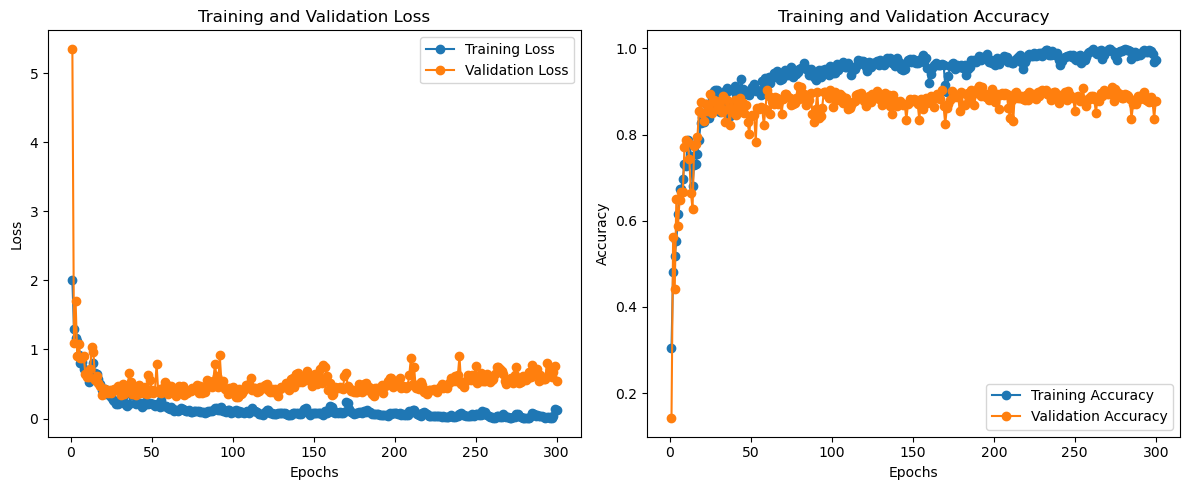

Model_Name: Musa_TCN_Model11 Test_Accuracy 0.9134615384615384


In [21]:
from datetime import datetime
    # Get the current time
current_time = datetime.now()
#dataset_name="WISDM"
#dataset_name="USCHAD"
dataset_name="PAMAP2"
#dataset_name="OpportunityUCI" #(31042, 25, 220) (31042,)
#dataset_name="Daphnet" #(29590, 25, 9)
#dataset_name="UCI_HAR" #(2922, 25, 562)

epochs=300

train_data_loader, test_data_loader,num_channels,num_classes,num_frames,kernel,dilation,max_time=Dataset_Selection(dataset_name=dataset_name)
#for model_no in range(1, 12):
model_no=11
print("Main_Current Time:", current_time)
model, model_name = Model_Selection(Model_No=model_no, channel=num_channels, num_classes=num_classes, frames=num_frames)
model_name = str(model_name).split('.')[-1].rstrip("'>")
file_name=dataset_name+"_"+model_name
json_file_path = os.path.join(result_path, f"{file_name}_results.json")
if not os.path.exists(json_file_path):
    train_accuracy,test_accuracy,train_losses,test_losses=run_model(Model=model, model_name=model_name, dataset_name=dataset_name,epochs=epochs)


else:
    with open(json_file_path, 'r') as json_file:
            loaded_result = json.load(json_file)
    print(f"File '{json_file_path}' already exists. Skipping creation.")

    train_accuracy = loaded_result["train_accuracy"]
    test_accuracy = loaded_result["test_accuracy"]
    train_losses = loaded_result["train_losses"]
    test_losses = loaded_result["test_losses"]

#print("Dataset Name:",dataset_name, "Model_Name:", model_name, "Training_Accuracy: ", train_accuracy,"Test_Accuracy", test_accuracy, "Training Loss",train_losses,"Testing Loss:",test_losses)
print( "Model_Name:", model_name, "Test_Accuracy", test_accuracy)

Dataset: PAMAP2 Model: Musa_TCN_Model11
Train Accuracy: 0.9917279411764706
Test Accuracy: 0.9723011363636364
Train Losses: 2.1318690215840057
Test Losses: 2.1344811509956014
Test True Labels: [9, 6, 8, 6, 2, 4, 6, 3, 6, 8, 2, 8, 2, 3, 4, 7, 11, 7, 4, 4, 11, 11, 10, 7, 2, 8, 4, 1, 1, 4, 10, 2, 6, 10, 9, 4, 7, 7, 0, 4, 8, 7, 7, 3, 1, 7, 0, 8, 9, 4, 4, 4, 11, 3, 6, 10, 6, 7, 11, 0, 9, 11, 11, 4, 6, 2, 8, 11, 6, 10, 10, 11, 9, 2, 11, 6, 2, 3, 8, 11, 7, 7, 4, 9, 11, 7, 1, 7, 3, 9, 3, 2, 11, 9, 11, 4, 11, 11, 11, 10, 4, 11, 9, 1, 7, 1, 1, 11, 3, 7, 8, 5, 4, 6, 7, 8, 7, 4, 10, 4, 10, 4, 6, 4, 0, 9, 4, 1, 6, 1, 4, 11, 2, 11, 2, 2, 8, 11, 4, 4, 6, 11, 11, 11, 7, 11, 6, 7, 6, 4, 11, 3, 9, 10, 8, 4, 8, 8, 2, 11, 7, 4, 8, 6, 1, 2, 0, 10, 1, 4, 10, 10, 4, 10, 10, 8, 10, 9, 4, 6, 11, 11, 8, 1, 3, 3, 3, 9, 1, 3, 7, 1, 4, 2, 2, 8, 7, 4, 5, 3, 10, 1, 3, 2, 1, 1, 6, 7, 1, 11, 4, 10, 4, 10, 9, 1, 3, 10, 7, 3, 4, 11, 2, 4, 10, 2, 3, 3, 7, 6, 1, 6, 8, 3, 1, 10, 8, 7, 11, 0, 9, 1, 1, 2, 7, 10, 10, 7, 4, 1, 

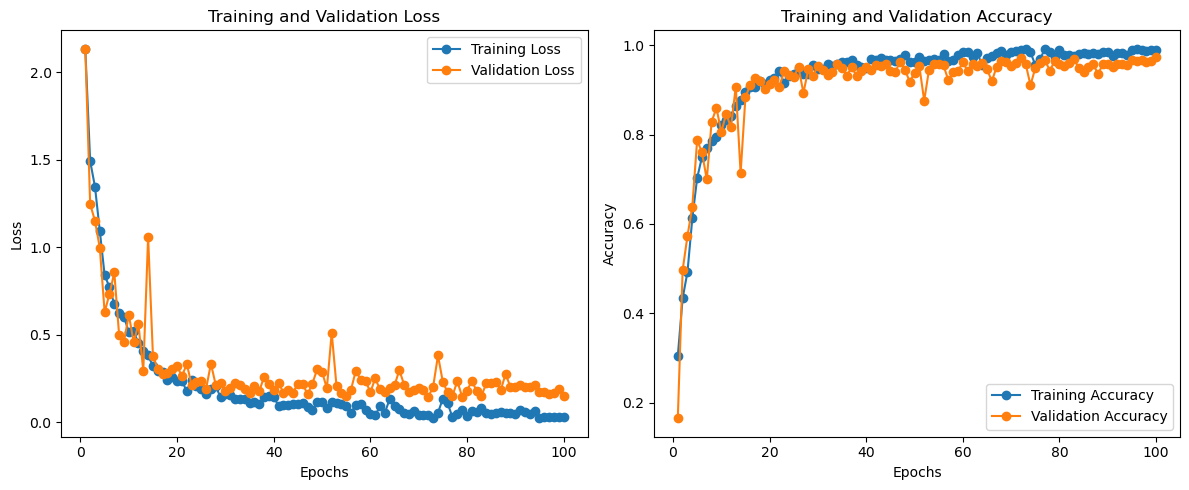

In [25]:
#dataset_name="WISDM"
#dataset_name="USCHAD"
dataset_name="PAMAP2"
#dataset_name="OpportunityUCI" #(31042, 25, 220) (31042,)
#dataset_name="Daphnet" #(29590, 25, 9)
#dataset_name="UCI_HAR" #(2922, 25, 562)
model_name="Musa_TCN_Model11"
result_path='/home/musa/Musa_Related/PostDoctoral_Research/HAR/Sensor/Result_Saving/'


#plot other matrix
import json
print("Dataset:",dataset_name,"Model:", model_name)
file_name=dataset_name+"_"+model_name
json_file_path = os.path.join(result_path, f"{file_name}_results.json")

# Load the JSON file
with open(json_file_path, 'r') as json_file:
    loaded_result = json.load(json_file)

import numpy as np
train_accuracy = loaded_result["train_accuracy"]
test_accuracy = loaded_result["test_accuracy"]
train_losses = loaded_result["train_losses"]
test_losses = loaded_result["test_losses"]
y_all = loaded_result["test_true"]
all_predict = loaded_result["test_predict"]

# Assuming the following are also in loaded_result
epoch_train_losses = loaded_result["epoch_train_losses"]
epoch_train_scores = loaded_result["epoch_train_scores"]
epoch_test_losses = loaded_result["epoch_test_losses"]
epoch_test_scores = loaded_result["epoch_test_scores"]


min_epoch_train_losses = loaded_result["min_epoch_train_losses"]
max_epoch_train_scores = loaded_result["max_epoch_train_scores"]
min_epoch_test_losses = loaded_result["min_epoch_test_losses"]
max_epoch_test_scores = loaded_result["max_epoch_test_scores"]



print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Train Losses: {train_losses}")
print(f"Test Losses: {test_losses}")
print(f"Test True Labels: {y_all}")
print(f"Test Predicted Labels: {all_predict}")

from sklearn.metrics import precision_recall_fscore_support

# Assuming y_true and y_pred are your true and predicted labels respectively
# Example:
y_true = np.array(y_all)
y_pred = np.array(all_predict)


# Compute precision, recall, f1-score for each class
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average=None)

# Compute overall metrics (average across all classes)
macro_precision, macro_recall, macro_f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
micro_precision, micro_recall, micro_f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average='micro')
weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

# Print results
print("Class-wise metrics:")
for i in range(len(precision)):
    print(f"Class {i}: Precision={precision[i]}, Recall={recall[i]}, F1-score={f1_score[i]}")

print("\nOverall metrics:")
print(f"Macro-average Precision={macro_precision}, Recall={macro_recall}, F1-score={macro_f1_score}")
print(f"Micro-average Precision={micro_precision}, Recall={micro_recall}, F1-score={micro_f1_score}")
print(f"Weighted-average Precision={weighted_precision}, Recall={weighted_recall}, F1-score={weighted_f1_score}")

import matplotlib.pyplot as plt
import numpy as np

# Load data from JSON
train_losses = np.array(loaded_result["epoch_train_losses"])
val_losses = np.array(loaded_result["epoch_test_losses"])
train_scores = np.array(loaded_result["epoch_train_scores"])
val_scores = np.array(loaded_result["epoch_test_scores"])

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, label='Training Loss', marker='o')
plt.plot(range(1, len(epoch_test_losses) + 1), epoch_test_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(epoch_train_scores) + 1), epoch_train_scores, label='Training Accuracy', marker='o')
plt.plot(range(1, len(epoch_test_scores) + 1), epoch_test_scores, label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()




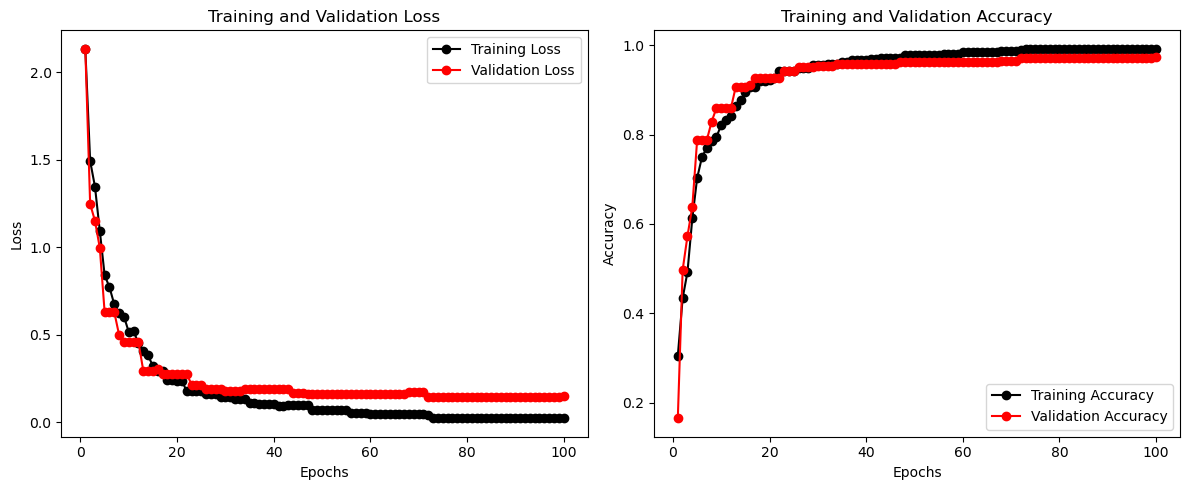

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(min_epoch_train_losses) + 1), min_epoch_train_losses, label='Training Loss', marker='o', color='black')
plt.plot(range(1, len(min_epoch_test_losses) + 1), min_epoch_test_losses, label='Validation Loss', marker='o', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(max_epoch_train_scores) + 1), max_epoch_train_scores, label='Training Accuracy', marker='o', color='black')
plt.plot(range(1, len(max_epoch_test_scores) + 1), max_epoch_test_scores, label='Validation Accuracy', marker='o', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



ValueError: x and y must have same first dimension, but have shapes (10,) and (300,)

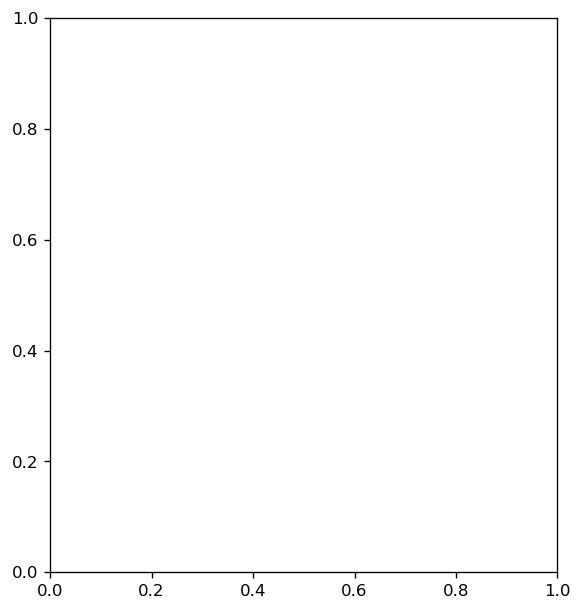

In [24]:
import os
import torch  # Ensure you have imported PyTorch
import matplotlib.pyplot as plt
import numpy as np

epochs = 10
fig_file_path = os.path.join(result_path, f"{dataset_name}_results.pdf")

plt.figure(figsize=(12, 6), dpi=120)
linewidth = 5
markersize = 10

# Plot accuracy curves
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), epoch_train_scores, 'b-o', label='Train Accuracy', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.plot(range(1, epochs + 1), epoch_test_scores, 'r-o', label='Test Accuracy', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Convert train and test losses to NumPy arrays
train_losses_numpy = [tensor.detach().cpu().numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor) for tensor in epoch_train_losses]
train_losses_array = np.stack(train_losses_numpy)

test_losses_numpy = [torch.tensor([item]).detach().cpu().numpy() if isinstance(item, float) else item.detach().cpu().numpy() if isinstance(item, torch.Tensor) else np.array(item) for item in epoch_test_losses]
test_losses_array = np.array(test_losses_numpy)

# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_losses_array, 'b-o', label='Train Loss', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.plot(range(1, epochs + 1), test_losses_array, 'r-o', label='Test Loss', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(fig_file_path, format='pdf')

# Display the figure
plt.show()


In [ ]:
my previous running Code



def run_model_previous function(Model=model, model_name="Musa_TCN_ModelX", dataset_name="USCHAD",epochs=1000):
    from datetime import datetime
    # Get the current time
    current_time = datetime.now()
    # Print the current time
    formatted_time = current_time.strftime("%Y-%m-%d %H:%M:%S")
    print("Run_model Current Time:", formatted_time)
    model = Model
    file_name=dataset_name+"_"+model_name
    print("Model_name:", model_name)
    import json
    print("Dataset name:", dataset_name, "Model_name:",model_name)
    import torch.optim as optim
    import time
    train_loader,val_loader=train_data_loader, test_data_loader
    #num_classes=num_classes
    #channel=num_channels
    batch_size = 32
    max_time = 5
    #channel = 3
    kernel=[3, 3, 3]
    dilation=[1, 2, 4]
    #frames=num_frames
    dp_rate=0.01
    TIME_LEN=4
    #del variables
    gc.collect()
    torch.cuda.memory_summary(device=None, abbreviated=False)
    print("Using torch", torch.__version__)
    torch.manual_seed(42)
    # device setup
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print("Device", device)
    # GPU operations have a separate seed we also want to set
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)
        torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark =False
    #model = MultiheadAttention(dk=3000, num_heads=30, num_classes=6)
    model.to(device)
    loss = nn.CrossEntropyLoss()
    learning_rate = 0.01
    optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
    model = torch.nn.DataParallel(model).cuda()
    model_solver = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()
    train_data_num = 2176
    test_data_num = 100
    iter_per_epoch = int(train_data_num / batch_size)
    max_acc = 0
    no_improve_epoch = 0
    n_iter = 0
    
    y_pr_final=0
    y_original=0
    model_1=0
    max_batch_acc=0
    max_batch_label=0
    max_batch_pred=0
    patiences=300
    max_batch_label_cat=[]
    max_batch_pred_cat=[]
    max_batch_acc_all=[]
    # Initialize variables to store predictions
    train_y_true = []
    train_y_pred = []
    test_y_true = []
    test_y_pred = []
    best_train_y_true = []
    best_train_y_pred = []
    best_test_y_true = []
    best_test_y_pred = []
    epoch_train_losses = []
    epoch_train_scores = []
    epoch_test_losses = []
    epoch_test_scores = []
    max_train_acc=0.0
    max_val_acc = 0.0
    no_improve_epoch = 0

    for epoch in range(epochs):
        print("\nTraining.............")
        model.train()
        start_time = time.time()
        train_acc = 0
        train_loss = 0
        for i, (data, labels) in enumerate(train_loader):
            data = data.to(device)
            labels = labels.to(device)
            n_iter += 1
            score, loss, acc = model_foreward(data, labels, model, criterion)
            model.zero_grad()
            loss.backward()
            model_solver.step()
            train_acc += acc
            train_loss += loss
            # Collect predictions for training set
            train_y_true.extend(labels.cpu().numpy())
            train_y_pred.extend(score.argmax(dim=1).cpu().numpy())

        train_acc /= float(i + 1)
        train_loss /= float(i + 1)
        print("*** Epoch: [%2d] time: %4.4f, "
            "train_loss: %.4f  train_ACC: %.6f ***"
            % (epoch + 1,  time.time() - start_time,
                train_loss.data, train_acc))
        if train_acc > max_train_acc:
            max_train_loss=train_loss
            max_train_acc = train_acc
            no_improve_epoch = 0
            
            best_train_y_true = train_y_true.copy()
            best_train_y_pred = train_y_pred.copy()
            print("Improved Train Accuracy")

            #print("Performance improved, saving the new model... Best accuracy: {}".format(max_train_acc))
        else:
            #no_improve_epoch += 1
            #print("No improvement in accuracy for {} epochs. Best accuracy: {}".format(no_improve_epoch, max_train_acc))
            print("No Improved Train Accuracy")
        start_time = time.time()
        # Evaluation on validation set
        with torch.no_grad():
            val_loss = 0
            val_acc = 0
            model.eval()
            for i, (data_test, labels_test) in enumerate(val_loader):
                data_test = data_test.to(device)
                labels_test = labels_test.to(device)
                score, loss, acc = model_foreward(data_test, labels_test, model, criterion)
                val_loss += loss
                val_acc += acc
                # Collect predictions for testing set
                test_y_true.extend(labels_test.cpu().numpy())
                test_y_pred.extend(score.argmax(dim=1).cpu().numpy())
                if acc > max_batch_acc:
                    max_batch_acc = acc
                    max_batch_label = labels_test
                    max_batch_pred = score
                if i == 0:
                    score_list = score
                    label_list = labels_test
                else:
                    score_list = torch.cat((score_list, score), 0)
                    label_list = torch.cat((label_list, labels_test), 0)

            val_loss = val_loss / float(i + 1)
            val_cc = get_acc(score_list,label_list)

            print("*** Epoch: [%2d], "
                "val_loss: %.6f,"
                "val_ACC: %.6f ***"
                % (epoch + 1, val_loss, val_cc))
            #print('Maximum Batch accuracy of this epoch:', max_batch_acc)
            # Save best model predictions
            epoch_train_losses.append(train_loss)
            epoch_train_scores.append(train_acc)
            epoch_test_losses.append(val_loss)
            epoch_test_scores.append(val_acc)
            if val_cc > max_val_acc:
                max_val_acc = val_cc
                max_test_loss=val_loss
                no_improve_epoch = 0
                best_test_y_true = test_y_true.copy()
                best_test_y_pred = test_y_pred.copy()
                print("Performance improved, saving the new model... Best accuracy: {}".format(max_val_acc))
            else:
                no_improve_epoch += 1
                print("No improvement in accuracy for {} epochs. Best accuracy: {}".format(no_improve_epoch, max_val_acc))
            if no_improve_epoch > patiences:
                print("Stopping training due to lack of improvement.")
                break
    max_train_acc = float(max_train_acc)
    max_val_acc = float(max_val_acc)
    max_train_loss = float(max_train_loss)
    max_test_loss = float(max_test_loss)
    # Create results dictionary
    results_dict = {
        "train_accuracy": max_train_acc,
        "test_accuracy": max_val_acc,
        "train_losses": max_train_loss,
        "test_losses": max_test_loss,
        "train_true": best_train_y_true,
        "train_predict": best_train_y_pred,
        "test_true": best_test_y_true,
        "test_predict": best_test_y_pred,
        "epoch_train_losses": epoch_train_losses,
        "epoch_train_scores": epoch_train_scores,
        "epoch_test_losses": epoch_test_losses,
        "epoch_test_scores": epoch_test_scores,
    }

    # Define file path
    json_file_path = os.path.join(result_path, f"{file_name}_results.json")

    # Save results to JSON file
    try:
        with open(json_file_path, 'w') as json_file:
            json.dump(results_dict, json_file, default=str)  # Use default=str for non-serializable types
        print(f"Results saved to '{json_file_path}'.")
    except Exception as e:
        print(f"Error saving results to '{json_file_path}': {e}")
    return max_train_acc,max_val_acc,max_train_loss,max_test_loss



SyntaxError: invalid syntax (244199250.py, line 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools

# Example data (replace with your actual data)
y_true = np.array(y_all)
y_pred = np.array(all_predict)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

#dataset_name="USCHAD"
#dataset_name="U
if dataset_name=="WISDM":
    #dataset_name="PAMAP2"
    classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']

if dataset_name=="PAMAP2":
    #dataset_name="PAMAP2"
    classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cm, classes=classes,
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cm, classes=classes, normalize=True,
                      title='Normalized confusion matrix')

plt.show()


NameError: name 'classes' is not defined

<Figure size 640x480 with 0 Axes>

ValueError: x and y must have same first dimension, but have shapes (5,) and (10,)

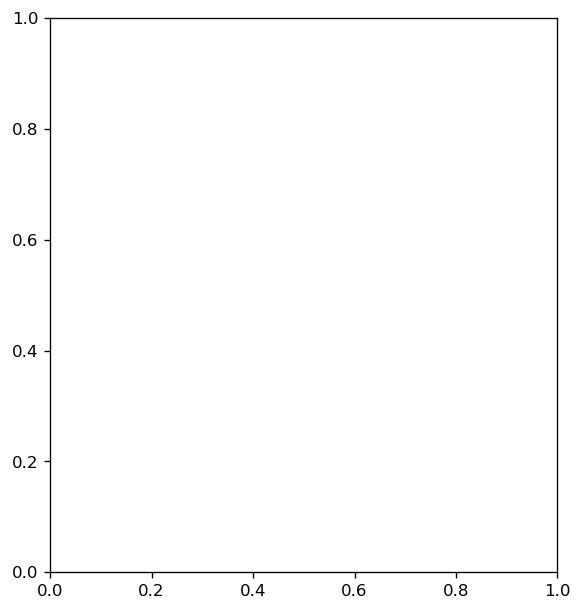

In [ ]:
epochs =5
fig_file_path = os.path.join(result_path, f"{dataset_name}_results.pdf")
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 6), dpi=120)
linewidth=5
markersize=10
# Plot accuracy curves
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), epoch_train_scores, 'b-o', label='Train Accuracy', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.plot(range(1, epochs+1), epoch_test_scores, 'r-o', label='Test Accuracy', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
type(train_losses)
#tensor_on_cpu = train_losses.cpu()  # Move to CPU
#print("train losses shape",np.array(train_losses).shape)
#train_losses_numpy = [tensor.detach().cpu().numpy() for tensor in train_losses]
train_losses_numpy = [tensor.detach().cpu().numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor) for tensor in epoch_train_losses]
train_losses_array = np.stack(train_losses_numpy)

#test_losses_numpy = [tensor.detach().cpu().numpy() for tensor in test_losses]
test_losses_numpy = [torch.Tensor([item]).detach().cpu().numpy() if isinstance(item, float) else item.detach().cpu().numpy() for item in epoch_test_losses]
test_losses_array = np.array(test_losses_numpy)
# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_losses_array, 'b-o', label='Train Loss', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.plot(range(1, epochs+1), test_losses_array, 'r-o', label='Test Loss', linewidth=linewidth, markersize=markersize, antialiased=True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(fig_file_path, format='pdf')
# Save the figure in a high-resolution vector format (e.g., PDF)
#plt.savefig('accuracy_loss_curves.pdf', format='pdf')

# Display the figure
plt.show()



TypeError: object of type 'float' has no len()

In [ ]:
#confusion matrix:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


label_name=[
    "a" ,"i" ,"u" ,"e" ,"o" ,
    "ka","ki","ku","ke","ko",
    "sa","shi","su","se","so",
    "ta","chi","tsu","te","to",
    "na","ni","nu","ne",
    "ha","hi","fu","he","ho",
    "ma","mi","mu","me",
    "ya",     "yu",     "yo",
    "ra",     "ru","re","ro",
    "wa",
]
    
cm=confusion_matrix(val_labels, pred)
plt.figure(figsize=(20,20))
df_cmx = pd.DataFrame(cm, index=label_name, columns=label_name)
sns.heatmap(df_cmx, annot=True, cbar=False, square=True, fmt="d")
plt.savefig('OurDataset_confusion_matrix.png')

##previous runn code

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

#importing other modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm
import torch

# imports from our file structure
from layers.Attention.MutliHeadAttention import MultiheadAttention
from utils.Data.HARDataset import getData

#################################################### setup ###########################################
print("Using torch", torch.__version__)
torch.manual_seed(42)
# device setup
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)
# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#################################################### model ############################################
def trainModel(Model, data_loader, loss_module, optimizer, epochs = 10):
  # put model in train mode
  Model.train()

  for epoch in tqdm(range(epochs)):
    for i, (sequence, labels) in enumerate(data_loader):
      sequence = sequence.to(device)
      labels = labels.to(device).long()

      # Forward Pass
      preds = model(sequence)
      # preds = preds.squeeze(dim = 1)
      loss = loss_module(preds, labels)

      # Backwards and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      if (i+1)%5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(data_loader)}], Loss: {loss.item():.4f}')


if __name__ == "__main__":
    # intializing model, loss and optimizer
    model = MultiheadAttention(3000)
    model.to(device)
    loss = nn.CrossEntropyLoss()
    learning_rate = 0.01
    optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

    # getting dataloaders
    train_data_loader, test_data_loader = getData()

    # train model
    trainModel(model, train_data_loader, loss, optimizer, 20000)

    # saving model
    state_dict = model.state_dict()
    dir = 'C:/Users/Admin/Desktop/CNN_HAR/Code/utils/SavedModels/'
    torch.save(state_dict, dir + 'mainmodel.tar')

    # reloading model
    new_model_state = torch.load(dir + 'mainmodel.tar', map_location=torch.device('cpu'))
    new_model = MultiheadAttention(3000)
    new_model.load_state_dict(new_model_state)

    # model Quantization
    quantized_model = torch.ao.quantization.quantize_dynamic(
                      new_model,  # the original model
                      {torch.nn.Linear},  # a set of layers to dynamically quantize
                      dtype=torch.qint8)

    # saving Quantized model
    q_state_dict = quantized_model.state_dict()
    torch.save(q_state_dict, dir + 'q_model.tar')



ModuleNotFoundError: No module named 'layers'

In [ ]:

class BertSelfAttention(nn.Module):
      def __init__(self, config):
        super().__init__()
        assert config["input_size"] #config["num_of_attention_heads"] == 0, "The hidden size is not a multiple of the number of attention heads"

        self.num_attention_heads = config['num_of_attention_heads']
        self.attention_head_size = int(config['input_size'] / config['num_of_attention_heads'])
        self.all_head_size = self.num_attention_heads * self.attention_head_size

        self.query = nn.Linear(config['input_size'], self.all_head_size)
        self.key = nn.Linear(config['input_size'], self.all_head_size)
        self.value = nn.Linear(config['input_size'], self.all_head_size)

        self.dense = nn.Linear(config['input_size'], config['output_size'])

      def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

      def forward(self, hidden_states):
        mixed_query_layer = self.query(hidden_states)                             # [Batch_size x Seq_length x Hidden_size]
        mixed_key_layer = self.key(hidden_states)                                 # [Batch_size x Seq_length x Hidden_size]
        mixed_value_layer = self.value(hidden_states)                             # [Batch_size x Seq_length x Hidden_size]

        query_layer = self.transpose_for_scores(mixed_query_layer)                # [Batch_size x Num_of_heads x Seq_length x Head_size]
        key_layer = self.transpose_for_scores(mixed_key_layer)                    # [Batch_size x Num_of_heads x Seq_length x Head_size]
        value_layer = self.transpose_for_scores(mixed_value_layer)                # [Batch_size x Num_of_heads x Seq_length x Head_size]


        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2)) # [Batch_size x Num_of_heads x Seq_length x Seq_length]
        attention_scores = attention_scores / math.sqrt(self.attention_head_size) # [Batch_size x Num_of_heads x Seq_length x Seq_length]
        attention_probs = nn.Softmax(dim=-1)(attention_scores)                    # [Batch_size x Num_of_heads x Seq_length x Seq_length]
        context_layer = torch.matmul(attention_probs, value_layer)                # [Batch_size x Num_of_heads x Seq_length x Head_size]

        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()            # [Batch_size x Seq_length x Num_of_heads x Head_size]
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,) # [Batch_size x Seq_length x Hidden_size]
        context_layer = context_layer.view(*new_context_layer_shape)              # [Batch_size x Seq_length x Hidden_size]

        output =  self.dense(context_layer)

        return output

#input=batch*frame*channel

#Facebook Transformer
import torch
import torch.nn as nn

class TimeSformer(nn.Module):
    def __init__(self, input_dim, num_frames, num_classes, patch_size=1, num_patches=16, embed_dims=256, num_heads=8, mlp_ratio=4):
        super().__init__()               #embeded dimension =dimension forward

        self.num_frames = num_frames

        # Embedding layer
        self.embed_dim = embed_dims
        self.proj = nn.Conv1d(input_dim, self.embed_dim, kernel_size=1)

        # Patch embedding layer
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.patch_embed = nn.Conv1d(self.embed_dim, self.embed_dim, kernel_size=self.patch_size, stride=self.patch_size)
        self.num_patch_features = self.embed_dim // self.patch_size

        # Positional encoding
        #self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, self.num_patch_features))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_frames, self.embed_dim)) #my editing

        # Transformer layers
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=num_heads, dim_feedforward=int(self.embed_dim*mlp_ratio)), num_layers=2)

        # Output layer
        #self.fc = nn.Linear(self.embed_dim * self.num_frames, num_classes)  #128*256,10= 32768*10
        self.fc = nn.Linear(256, num_classes)  #128*256,10= 32768*10

    def forward(self, x):  #(16,1,128)
        # Embedding layer
        x = self.proj(x)  #torch.Size([16, 256, 128])
        #print('projection x',x.shape)

        # Patch embedding layer
        x = self.patch_embed(x)#torch.Size([16, 256, 16])   128/8
        #print('patch_embed.shape',x.shape)
        x = x.flatten(2).transpose(1, 2)  #([16, 16, 256])

        #print('x.shape',x.shape)
        #print('Pose_embed.shape',self.pos_embed.shape) #Pose_embed.shape torch.Size([1, 16, 32])

        # Positional encoding
        x = x + self.pos_embed  #x+pose_embed torch.Size([16, 16, 256])
        #print('x+pose_embed', x.shape)

        # Transformer layers
        x = self.transformer(x)
        #print('transformer shape',x.shape)#([16, 16, 256]  #transformer shape torch.Size([16, 128, 256])


        # Output layer
        #x = x.flatten(1)
        #print('shape of flatten',x.shape)
        x = self.fc(x)
        return x
#input=batch*channel*frame

In [ ]:
#complextity
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = Musa_TCN_Model11(channel=6, num_classes=6)
print(f"Total trainable parameters: {count_parameters(model)}")


#torchsummary 
#pip install torchsummary
from torchsummary import summary
# Assuming your model is on the right device
model = Musa_TCN_Model11(channel=6, num_classes=6)
model.to('cuda' if torch.cuda.is_available() else 'cpu')  # Move to GPU if available
summary(model, input_size=(6, 512))  # Adjust input size based on your input data


#depth
from torch import nn

def count_layers(model):
    conv_layers = 0
    fc_layers = 0
    other_layers = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv1d, nn.Conv2d, nn.Conv3d)):
            conv_layers += 1
        elif isinstance(module, (nn.Linear)):
            fc_layers += 1
        else:
            other_layers += 1  # Count all other layers, such as batch normalization, ReLU, etc.

    print(f"Total convolutional layers: {conv_layers}")
    print(f"Total fully connected layers: {fc_layers}")
    print(f"Other layers (e.g., BatchNorm, Activation): {other_layers}")

#model = Musa_TCN_Model11(channel=6, num_classes=6)
#count_layers(model)